# Fault Tree Analysis of Chemical Plant Cybersecurity-Safety Failure

This notebook performs Fault Tree Analysis for a chemical plant reactor safety case.

The top event is:

**Reactor overpressure leading to explosion risk**

The model includes both:

- Physical safety failures
- Cybersecurity-related failures
- Human/technical protection failures

The notebook uses:

1. `pfta` library to define the FTA model
2. A custom Python FTA engine to calculate probabilities, gate outputs, and minimal cut sets

In [1]:
# Install the PFTA library, Graphviz, and pandas
!pip install pfta graphviz pandas

# Install system Graphviz package for diagram rendering in Colab
!apt-get install -y graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


## Import Required Libraries

This block imports all libraries needed for the fault tree analysis.

- `pfta` is used to create a fault tree from text.
- `dataclass` is used to define simple node classes.
- `field` is used to create default empty child lists.
- `product` is used to combine cut sets for AND gates.
- `pandas` is used to display result tables.
- `graphviz` is used to draw the fault tree.
- `IPython.display` is used to show images and tables in Colab.

In [2]:
# Import FaultTree class from PFTA library
from pfta.core import FaultTree as PFTATree

# Import dataclass tools for creating simple classes
from dataclasses import dataclass, field

# Import product to create combinations of cut sets
from itertools import product

# Import pandas for table creation
import pandas as pd

# Import Graphviz for drawing the fault tree
from graphviz import Digraph

# Import display tools for Colab output
from IPython.display import Image, display

##  Define the Fault Tree Using PFTA Text Format

This block defines the same fault tree using the PFTA library format.

The model contains:

- Basic events A to I
- Intermediate gates G1 to G6
- Top event TOP

Each basic event has a fixed probability.

Each gate combines events using logical gate types such as:

- OR
- AND
- XOR
- PAND
- INHIBIT

In [3]:
# Define the complete fault tree in PFTA text format
fta_text = """
- time_unit: hour
- times: 1

Event: A
- label: Cooling pump mechanical failure
- model_type: Fixed
- probability: 0.05
- intensity: 0

Event: B
- label: Heat exchanger fouling
- model_type: Fixed
- probability: 0.04
- intensity: 0

Event: C
- label: Alarm suppression by malware
- model_type: Fixed
- probability: 0.012
- intensity: 0

Event: D
- label: Emergency shutdown failure
- model_type: Fixed
- probability: 0.02
- intensity: 0

Event: E
- label: Weak remote access password
- model_type: Fixed
- probability: 0.015
- intensity: 0

Event: F
- label: Stolen operator credentials
- model_type: Fixed
- probability: 0.018
- intensity: 0

Event: G
- label: Attacker changes reactor setpoint
- model_type: Fixed
- probability: 0.018
- intensity: 0

Event: H
- label: Malicious PLC logic modification
- model_type: Fixed
- probability: 0.01
- intensity: 0

Event: I
- label: Safety interlock bypass condition
- model_type: Fixed
- probability: 0.008
- intensity: 0

Gate: G1
- label: Cooling failure
- type: OR
- inputs: A, B

Gate: G2
- label: Remote access compromise
- type: OR
- inputs: E, F

Gate: G3
- label: Malicious control action
- type: AND
- inputs: G, H

Gate: G4
- label: Cyber initiated heat increase
- type: AND
- inputs: G2, G3

Gate: G5
- label: Safety shutdown blocked
- type: AND
- inputs: D, I

Gate: G6
- label: Failed safety response
- type: OR
- inputs: C, G5

Gate: TOP
- label: Reactor overpressure leading to explosion risk
- type: OR
- inputs: G1, G4, G6
"""

# Create the PFTA model from the text definition
pfta_model = PFTATree(fta_text)

# Print confirmation message
print("PFTA model created successfully.")

PFTA model created successfully.


##  Define the Custom Node Class

This block defines a simple `Node` class.

Each node represents either:

- A basic event
- A logic gate

Each node stores:

- Name
- Type
- Probability
- Children/input nodes

In [4]:
# Define a simple data class for fault tree nodes
@dataclass
class Node:
    # Name of the event or gate
    name: str

    # Node type: BASIC, OR, AND, XOR, PAND, or INHIBIT
    kind: str

    # Probability value for basic events
    p: float = None

    # Child nodes connected to this node
    children: list = field(default_factory=list)

##  Helper Functions

This block defines helper functions.

These functions:

- Format probability values
- Calculate gate output probabilities
- Multiply values
- Minimize cut sets

In [5]:
# Format probability values neatly
def fmt(x):
    # Keep 5 decimal places, then remove unnecessary zeros
    return f"{x:.5f}".rstrip("0").rstrip(".")


# Multiply a list of values together
def product_value(values):
    # Start multiplication from 1
    r = 1

    # Multiply each value
    for v in values:
        r *= v

    # Return final product
    return r


# Calculate output probability of a gate
def gate(kind, ps):
    # AND, PAND, and INHIBIT are treated as multiplication in this simple model
    if kind in ["AND", "PAND", "INHIBIT"]:
        r = 1

        # Multiply all input probabilities
        for p in ps:
            r *= p

        return r

    # OR gate probability: 1 - product of all failure complements
    if kind == "OR":
        r = 1

        # Multiply complements of input probabilities
        for p in ps:
            r *= (1 - p)

        return 1 - r

    # XOR gate probability: exactly one input occurs
    if kind == "XOR":
        return sum(
            p * product_value(
                1 - q for j, q in enumerate(ps) if j != i
            )
            for i, p in enumerate(ps)
        )

    # Raise error if gate type is unsupported
    raise ValueError("Unsupported gate type")


# Remove non-minimal cut sets
def minimize(cutsets):
    # Convert cut sets to frozensets and remove duplicates
    unique = sorted(
        set(frozenset(c) for c in cutsets),
        key=lambda x: (len(x), sorted(x))
    )

    # Store minimal cut sets
    minimal = []

    # Check each cut set
    for c in unique:
        # Add only if no smaller existing cut set is already inside it
        if not any(m.issubset(c) for m in minimal):
            minimal.append(c)

    # Convert frozensets back to normal sets
    return [set(c) for c in minimal]

## Define the Custom FTA Class

This class performs the main analysis.

It can:

1. Evaluate the top event probability
2. List all nodes
3. Create a gate-by-gate analysis table
4. Create a probability table
5. Generate minimal cut sets
6. Draw the fault tree diagram

In [6]:
# Define the custom Fault Tree Analysis class
class FTA:
    # Constructor stores the top event
    def __init__(self, top):
        self.top = top

    # Evaluate probability of the whole fault tree
    def evaluate(self):
        # Dictionary to store probability of each node
        probs = {}

        # Recursive function to solve each node
        def solve(n):
            # If node is a basic event, return its probability
            if n.kind == "BASIC":
                probs[n.name] = n.p
                return n.p

            # Evaluate child node probabilities
            child_probs = [solve(c) for c in n.children]

            # Calculate this gate output probability
            probs[n.name] = gate(n.kind, child_probs)

            # Return this node probability
            return probs[n.name]

        # Start solving from the top event
        return solve(self.top), probs

    # Return all nodes in the tree
    def nodes(self):
        # Store all nodes
        out = []

        # Recursive walk through tree
        def walk(n):
            # Add current node
            out.append(n)

            # Visit all child nodes
            for c in n.children:
                walk(c)

        # Start walk from top event
        walk(self.top)

        # Return list of nodes
        return out

    # Create gate-by-gate analysis table
    def gate_analysis(self):
        # Evaluate probabilities first
        _, probs = self.evaluate()

        # Store table rows
        rows = []

        # Go through all nodes
        for n in self.nodes():
            # Only include gate nodes
            if n.kind != "BASIC":
                rows.append({
                    "Gate": n.name,
                    "Type": n.kind,
                    "Inputs": " | ".join(c.name for c in n.children),
                    "Input Probabilities": " | ".join(fmt(probs[c.name]) for c in n.children),
                    "Output": fmt(probs[n.name])
                })

        # Return table
        return pd.DataFrame(rows)

    # Create probability table for all nodes
    def probability_table(self):
        # Evaluate probabilities first
        _, probs = self.evaluate()

        # Create table for every node
        return pd.DataFrame([
            {
                "Node": n.name,
                "Type": n.kind,
                "Probability": fmt(probs[n.name])
            }
            for n in self.nodes()
        ])

    # Generate minimal cut sets
    def cutsets(self, n=None):
        # Use top event if no node is provided
        n = n or self.top

        # Basic event cut set is itself
        if n.kind == "BASIC":
            return [{n.name}]

        # Get cut sets from child nodes
        child_sets = [self.cutsets(c) for c in n.children]

        # OR and XOR gates combine child cut sets
        if n.kind in ["OR", "XOR"]:
            return minimize([cs for group in child_sets for cs in group])

        # AND, PAND, and INHIBIT gates combine child cut sets together
        if n.kind in ["AND", "PAND", "INHIBIT"]:
            return minimize([
                set().union(*combo)
                for combo in product(*child_sets)
            ])

    # Convert cut sets into a table
    def cutset_table(self, sets):
        # Create dataframe for cut sets
        return pd.DataFrame([
            {
                "ID": f"MCS-{i}",
                "Cut Set": " + ".join(sorted(s)),
                "Order": len(s)
            }
            for i, s in enumerate(sets, 1)
        ])

    # Draw the fault tree diagram
    def draw(self, file="chemical_plant_fta"):
        # Create Graphviz diagram
        dot = Digraph(format="png")

        # Draw from top to bottom
        dot.attr(rankdir="TB", splines="ortho")

        # Recursive function to add nodes and edges
        def add(n):
            # Label basic events with probability
            label = f"{n.name}\nP={fmt(n.p)}" if n.kind == "BASIC" else f"{n.name}\n[{n.kind}]"

            # Basic events are boxes, gates are ellipses
            shape = "box" if n.kind == "BASIC" else "ellipse"

            # Add node to diagram
            dot.node(n.name, label, shape=shape)

            # Add child nodes
            for c in n.children:
                add(c)

                # Connect parent to child
                dot.edge(n.name, c.name, arrowhead="none")

        # Start drawing from top event
        add(self.top)

        # Render diagram as PNG
        path = dot.render(file, cleanup=True)

        # Display diagram in Colab
        display(Image(filename=path))

##  Build the Fault Tree Case Study

This block manually builds the same case study for the custom analysis engine.

Basic events represent component failures or cyber failures.

Intermediate gates combine basic events.

The top event is:

**Reactor overpressure leading to explosion risk**

In [7]:
# Basic event A: cooling pump mechanical failure
A = Node("Cooling pump mechanical failure", "BASIC", 0.05)

# Basic event B: heat exchanger fouling
B = Node("Heat exchanger fouling", "BASIC", 0.04)

# Basic event C: cyber attack suppresses alarm
C = Node("Alarm suppression by malware", "BASIC", 0.012)

# Basic event D: emergency shutdown fails
D = Node("Emergency shutdown failure", "BASIC", 0.02)

# Basic event E: weak password allows remote access
E = Node("Weak remote access password", "BASIC", 0.015)

# Basic event F: stolen credentials allow access
F = Node("Stolen operator credentials", "BASIC", 0.018)

# Basic event G: attacker changes reactor setpoint
G = Node("Attacker changes reactor setpoint", "BASIC", 0.018)

# Basic event H: malicious PLC logic modification
H = Node("Malicious PLC logic modification", "BASIC", 0.01)

# Basic event I: safety interlock bypass condition
I = Node("Safety interlock bypass condition", "BASIC", 0.008)


# Gate G1: cooling failure occurs if A or B occurs
G1 = Node("Cooling failure", "OR", children=[A, B])

# Gate G2: remote access compromise occurs if E or F occurs
G2 = Node("Remote access compromise", "XOR", children=[E, F])

# Gate G3: malicious control action requires both G and H
G3 = Node("Malicious control action", "PAND", children=[G, H])

# Gate G4: cyber initiated heat increase requires G2 and G3
G4 = Node("Cyber initiated heat increase", "AND", children=[G2, G3])

# Gate G5: safety shutdown blocked requires D and I
G5 = Node("Safety shutdown blocked", "INHIBIT", children=[D, I])

# Gate G6: failed safety response occurs if C or G5 occurs
G6 = Node("Failed safety response", "OR", children=[C, G5])

# Top event occurs if G1, G4, or G6 occurs
TOP = Node(
    "Reactor overpressure leading to explosion risk",
    "OR",
    children=[G1, G4, G6]
)

## Run the Fault Tree Analysis

This block runs the analysis.

It displays:

- Top event probability
- Fault tree diagram
- Probability table
- Gate-by-gate analysis
- MOCUS minimal cut sets
- MICSUP minimal cut sets

In this simple code, MOCUS and MICSUP are calculated using the same cut set function, so they should match.

CHEMICAL PLANT CYBERSECURITY-SAFETY FTA
Top Event Probability: 0.09909


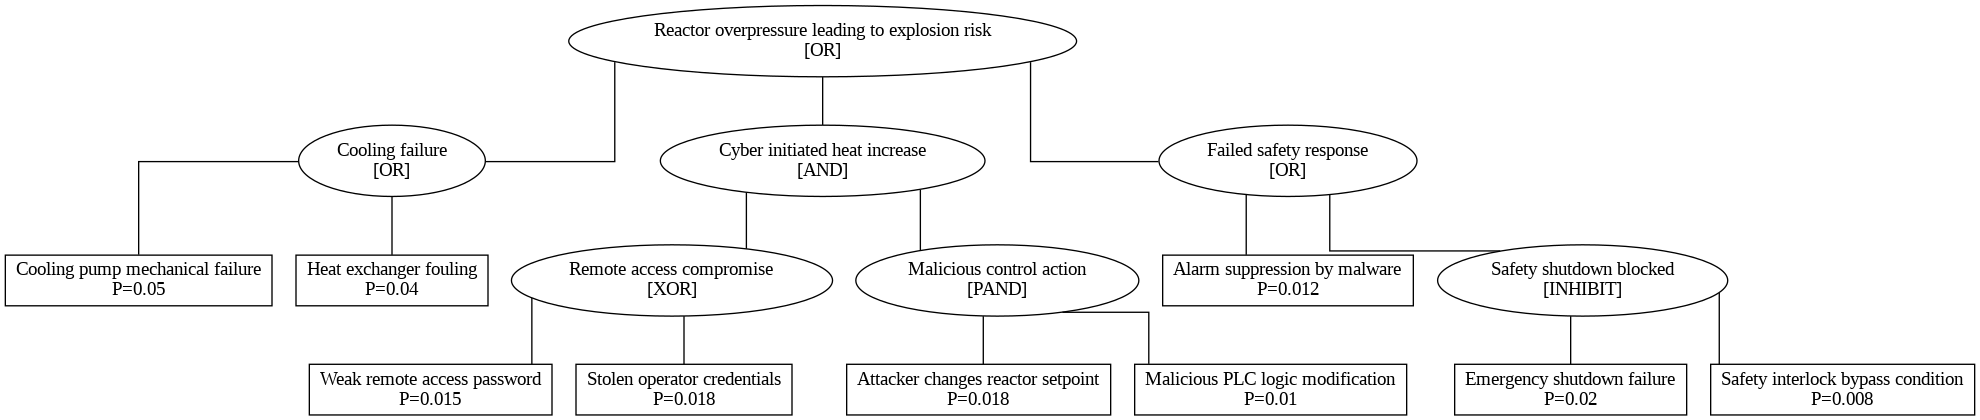


1. Probability Table


,Node,Type,Probability
0,Reactor overpressure leading to explosion risk,OR,0.09909
1,Cooling failure,OR,0.088
2,Cooling pump mechanical failure,BASIC,0.05
3,Heat exchanger fouling,BASIC,0.04
4,Cyber initiated heat increase,AND,0.00001
5,Remote access compromise,XOR,0.03246
6,Weak remote access password,BASIC,0.015
7,Stolen operator credentials,BASIC,0.018
8,Malicious control action,PAND,0.00018
9,Attacker changes reactor setpoint,BASIC,0.018



2. Gate-by-Gate Analysis


,Gate,Type,Inputs,Input Probabilities,Output
0,Reactor overpressure leading to explosion risk,OR,Cooling failure | Cyber initiated heat increas...,0.088 | 0.00001 | 0.01216,0.09909
1,Cooling failure,OR,Cooling pump mechanical failure | Heat exchang...,0.05 | 0.04,0.088
2,Cyber initiated heat increase,AND,Remote access compromise | Malicious control a...,0.03246 | 0.00018,0.00001
3,Remote access compromise,XOR,Weak remote access password | Stolen operator ...,0.015 | 0.018,0.03246
4,Malicious control action,PAND,Attacker changes reactor setpoint | Malicious ...,0.018 | 0.01,0.00018
5,Failed safety response,OR,Alarm suppression by malware | Safety shutdown...,0.012 | 0.00016,0.01216
6,Safety shutdown blocked,INHIBIT,Emergency shutdown failure | Safety interlock ...,0.02 | 0.008,0.00016



3. MOCUS Minimal Cut Sets


,ID,Cut Set,Order
0,MCS-1,Alarm suppression by malware,1
1,MCS-2,Cooling pump mechanical failure,1
2,MCS-3,Heat exchanger fouling,1
3,MCS-4,Emergency shutdown failure + Safety interlock ...,2
4,MCS-5,Attacker changes reactor setpoint + Malicious ...,3
5,MCS-6,Attacker changes reactor setpoint + Malicious ...,3



4. MICSUP Minimal Cut Sets


,ID,Cut Set,Order
0,MCS-1,Alarm suppression by malware,1
1,MCS-2,Cooling pump mechanical failure,1
2,MCS-3,Heat exchanger fouling,1
3,MCS-4,Emergency shutdown failure + Safety interlock ...,2
4,MCS-5,Attacker changes reactor setpoint + Malicious ...,3
5,MCS-6,Attacker changes reactor setpoint + Malicious ...,3



MOCUS and MICSUP match: True


In [8]:
# Create FTA object using the top event
fta = FTA(TOP)

# Evaluate top event probability
top_probability, _ = fta.evaluate()

# Print heading
print("=" * 80)
print("CHEMICAL PLANT CYBERSECURITY-SAFETY FTA")
print("=" * 80)

# Print top event probability
print("Top Event Probability:", fmt(top_probability))

# Draw and display the fault tree
fta.draw()

# Display probability table
print("\n1. Probability Table")
display(fta.probability_table())

# Display gate-by-gate analysis
print("\n2. Gate-by-Gate Analysis")
display(fta.gate_analysis())

# Generate MOCUS minimal cut sets
mocus = fta.cutsets()

# Generate MICSUP minimal cut sets
micsup = fta.cutsets()

# Display MOCUS cut set table
print("\n3. MOCUS Minimal Cut Sets")
display(fta.cutset_table(mocus))

# Display MICSUP cut set table
print("\n4. MICSUP Minimal Cut Sets")
display(fta.cutset_table(micsup))

# Compare MOCUS and MICSUP results
print("\nMOCUS and MICSUP match:", sorted(map(sorted, mocus)) == sorted(map(sorted, micsup)))